<a href="https://colab.research.google.com/github/Parth4210/machine-learning-foundations/blob/main/ValorantMatchPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Uploading the dataset
from google.colab import files
dataset = files.upload()

Saving VCT_2024.csv to VCT_2024.csv


In [3]:
# Loading the dataset
filepath = "/content/VCT_2024.csv"
player_stats = pd.read_csv(filepath)

In [4]:
# Printing few rows from the dataframe created
player_stats.head()

,Region,Event,Player,Team Abbreviated,Team,Rnd,R,ACS,K:D,KAST,...,CL%,CL,CW,CP,KMax,K,D,A,FK,FD
0,EMEA,Champions Tour 2024: EMEA Kickoff,AtaKaptan,FUT,FUT Esports,182,1.22,216.9,1.23,0.76,...,0.17,4/23,4.0,23.0,30,140,114,92,7,13
1,EMEA,Champions Tour 2024: EMEA Kickoff,N4RRATE,KC,Karmine Corp,383,1.21,249.9,1.27,0.78,...,0.15,5/33,5.0,33.0,40,342,269,125,47,31
2,EMEA,Champions Tour 2024: EMEA Kickoff,MiniBoo,TH,Team Heretics,208,1.19,254.7,1.22,0.69,...,0.40,6/15,6.0,15.0,25,184,151,39,45,36
3,EMEA,Champions Tour 2024: EMEA Kickoff,Chronicle,FNC,FNATIC,88,1.15,218.0,1.20,0.76,...,0.42,5/12,5.0,12.0,21,65,54,50,8,4
4,EMEA,Champions Tour 2024: EMEA Kickoff,Cloud,GX,GIANTX,124,1.15,241.3,1.17,0.71,...,0.13,2/16,2.0,16.0,22,104,89,45,10,8


In [16]:
# Checking the datatypes of the columns
player_stats.dtypes

,0
Region,object
Event,object
Player,object
Team Abbreviated,object
Team,object
Rnd,int64
R,float64
ACS,float64
K:D,float64
KAST,float64


In [5]:
# Checking for missing/null values
player_stats.isnull().sum()

,0
Region,0
Event,0
Player,0
Team Abbreviated,0
Team,0
Rnd,0
R,231
ACS,0
K:D,0
KAST,231


In [25]:
# Fixing the missing values(replacing them with zero as they are numerical values and they're unknown to avoid any problem occuring with the model)
player_stats = player_stats.drop(["CL"], axis=1)

# convert the remaining appropriate columns to float64.
for col in ['R', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%', 'CL%', 'CW', 'CP']:
    if col in player_stats.columns:
        player_stats[col] = pd.to_numeric(player_stats[col], errors='coerce').fillna(0)

# Convert relevant columns to float64 after handling missing values.
for col in ['R', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%', 'CL%', 'CW', 'CP']:
    if col in player_stats.columns:
        player_stats[col] = player_stats[col].astype('float64')

# Display data types to confirm changes
player_stats.dtypes

,0
Region,object
Event,object
Player,object
Team Abbreviated,object
Team,object
Rnd,int64
R,float64
ACS,float64
K:D,float64
KAST,float64


The goal is to predict clutches won for a given player on the basis of required features


In [28]:
# Selecting the required features and the variable to predict
features = ['R', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%', 'CL%', 'CP']
x = player_stats[features]
y = player_stats['CW']

In [30]:
# Splitting the training and testing data
train_x, val_x, train_y, val_y = train_test_split(x, y, test_size = 0.3, random_state = 1)

In [27]:
# Creating the model and fitting the data
model = RandomForestClassifier(random_state=1)
model.fit(train_x,train_y)

RandomForestClassifier(random_state=1)

In [31]:
# Make predictions on the validation set
val_predictions = model.predict(val_x)

# Calculate the Mean Absolute Error
mae = mean_absolute_error(val_y, val_predictions)
print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 0.00


In [32]:
#remove 'CL%' and 'CP' from the features as 'CW' can be derived from them.
features_corrected = ['R', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']
x_corrected = player_stats[features_corrected]
y = player_stats['CW']

In [33]:
# Splitting the training and testing data with corrected features
train_x_corrected, val_x_corrected, train_y_corrected, val_y_corrected = train_test_split(x_corrected, y, test_size=0.3, random_state=1)

In [34]:
# Creating and fitting the model with corrected features
model_corrected = RandomForestClassifier(random_state=1)
model_corrected.fit(train_x_corrected, train_y_corrected)

RandomForestClassifier(random_state=1)

In [35]:
# Make predictions on the validation set with corrected features
val_predictions_corrected = model_corrected.predict(val_x_corrected)

# Calculate the Mean Absolute Error with corrected features
mae_corrected = mean_absolute_error(val_y_corrected, val_predictions_corrected)
print(f"Mean Absolute Error (corrected features): {mae_corrected:.2f}")

Mean Absolute Error (corrected features): 1.90


[[74  4  2  2  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  2  3  1  3  2  2  2  0  0  0  0  0  0  0  0]
 [ 0  4  2  2  1  2  0  0  1  0  0  0  0  0  0  0]
 [ 1  2  3  4  2  7  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  5  2  6  4  0  2  1  1  0  0  0  0  0  0]
 [ 0  1  5  4  3  2  1  2  0  0  1  0  0  0  0  0]
 [ 0  1  5  2  2  6  0  4  0  0  0  0  0  0  0  0]
 [ 0  2  0  4  1  1  0  0  1  2  0  1  0  0  0  0]
 [ 0  3  2  0  0  1  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  1  1  1  0  3  0  0  0  0  0  0  0  0  1]
 [ 0  1  2  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  3  0  0  1  0  0  0  1  1  0  0  0  0  0]
 [ 0  1  0  0  1  0  0  0  0  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]]


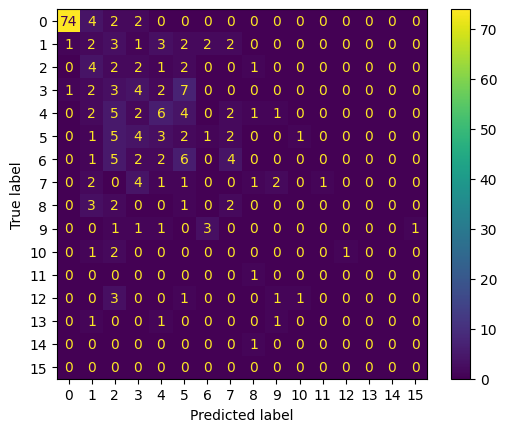

In [40]:
# Creating a confusion matrix for the predictions and displaying it
cm = confusion_matrix(val_y_corrected, val_predictions_corrected)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Using the Model for Prediction

To predict 'Clutches Won' for a new player, you need to provide their statistics for the features the model was trained on. These features are: `'R', 'ACS', 'K:D', 'KAST', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'`.

Here's an example:

In [36]:
# Predicting for a hypothetically created player
new_player_data = pd.DataFrame({
    'R': [1.05],     # Rating
    'ACS': [220.5],  # Average Combat Score
    'K:D': [1.15],   # Kill/Death Ratio
    'KAST': [0.72],  # Kill, Assist, Survive, Trade %
    'ADR': [135.2],  # Average Damage per Round
    'KPR': [0.75],   # Kills per Round
    'APR': [0.28],   # Assists per Round
    'FKPR': [0.12],  # First Kills per Round
    'FDPR': [0.08],  # First Deaths per Round
    'HS%': [0.25]    # Headshot Percentage
})

new_player_data = new_player_data[features_corrected]

# Make a prediction for the new player
predicted_clutches_won = model_corrected.predict(new_player_data)

print(f"Predicted Clutches Won for the new player: {predicted_clutches_won[0]:.2f}")

Predicted Clutches Won for the new player: 6.00
